# Butterworth Filter - Complete Demonstration

This notebook demonstrates the `ButterworthFilter` audio component in AudioPlayground.

**Features covered:**
- Low-pass, High-pass, and Band-pass filters
- Frequency response visualization
- Audio filtering examples
- Real-time parameter adjustment
- Integration with other components

In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from scipy.signal import lfilter

from constants import DEFAULT_SAMPLE_RATE
from engine import (
    ButterworthFilter,
    Chain,
    NoiseGenerator,
    SawtoothOscillator,
    SquareOscillator,
    apply_filter,
    butter,
)

# Set up plotting
plt.style.use("dark_background")
%matplotlib inline

print("✅ Imports successful!")
print(f"Sample rate: {DEFAULT_SAMPLE_RATE} Hz")

✅ Imports successful!
Sample rate: 44100 Hz


## 1. Basic Filter Creation

In [2]:
# Create different filter types
lpf = ButterworthFilter(cutoff=1000, filter_type="low", order=4)
hpf = ButterworthFilter(cutoff=1000, filter_type="high", order=4)
bpf = ButterworthFilter(cutoff=(500, 2000), filter_type="band", order=4)

print("Created filters:")
print(f"  Low-pass:  cutoff={lpf.cutoff} Hz, order={lpf.order}")
print(f"  High-pass: cutoff={hpf.cutoff} Hz, order={hpf.order}")
print(f"  Band-pass: cutoff={bpf.cutoff} Hz, order={bpf.order}")

Created filters:
  Low-pass:  cutoff=1000 Hz, order=4
  High-pass: cutoff=1000 Hz, order=4
  Band-pass: cutoff=(500, 2000) Hz, order=4


## 2. Frequency Response Visualization

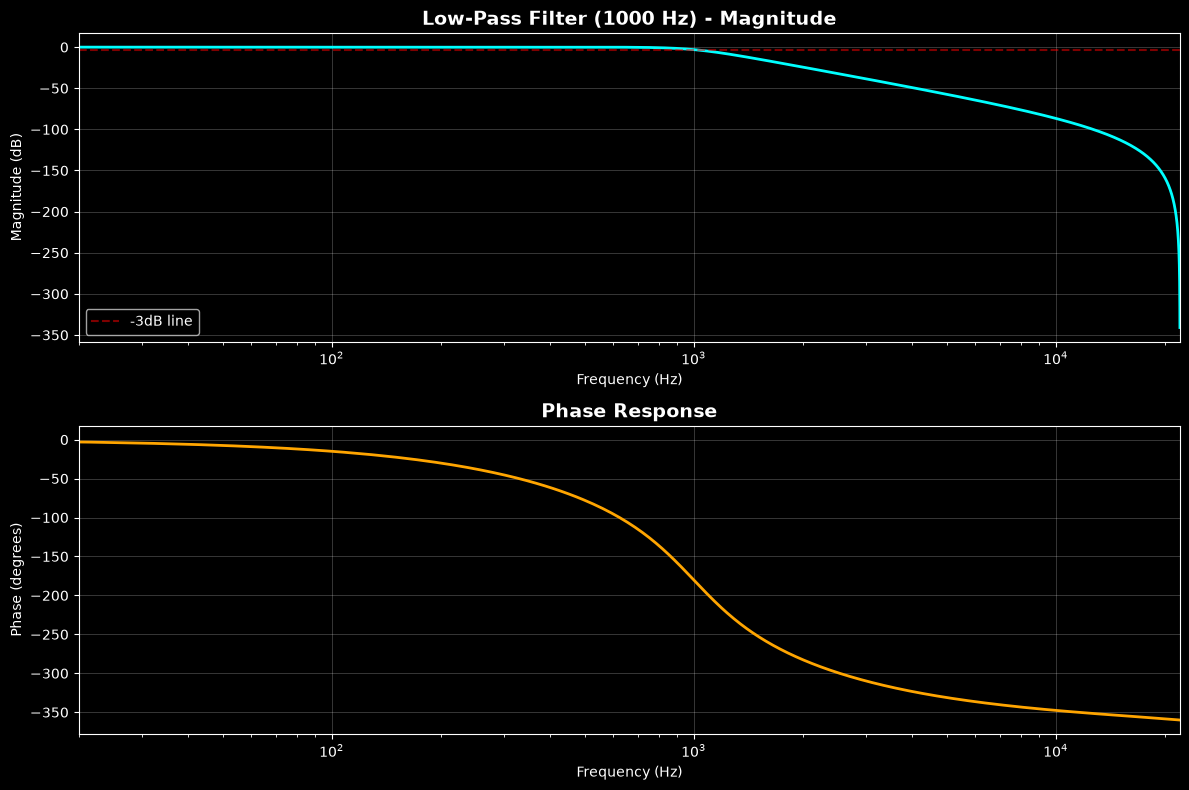

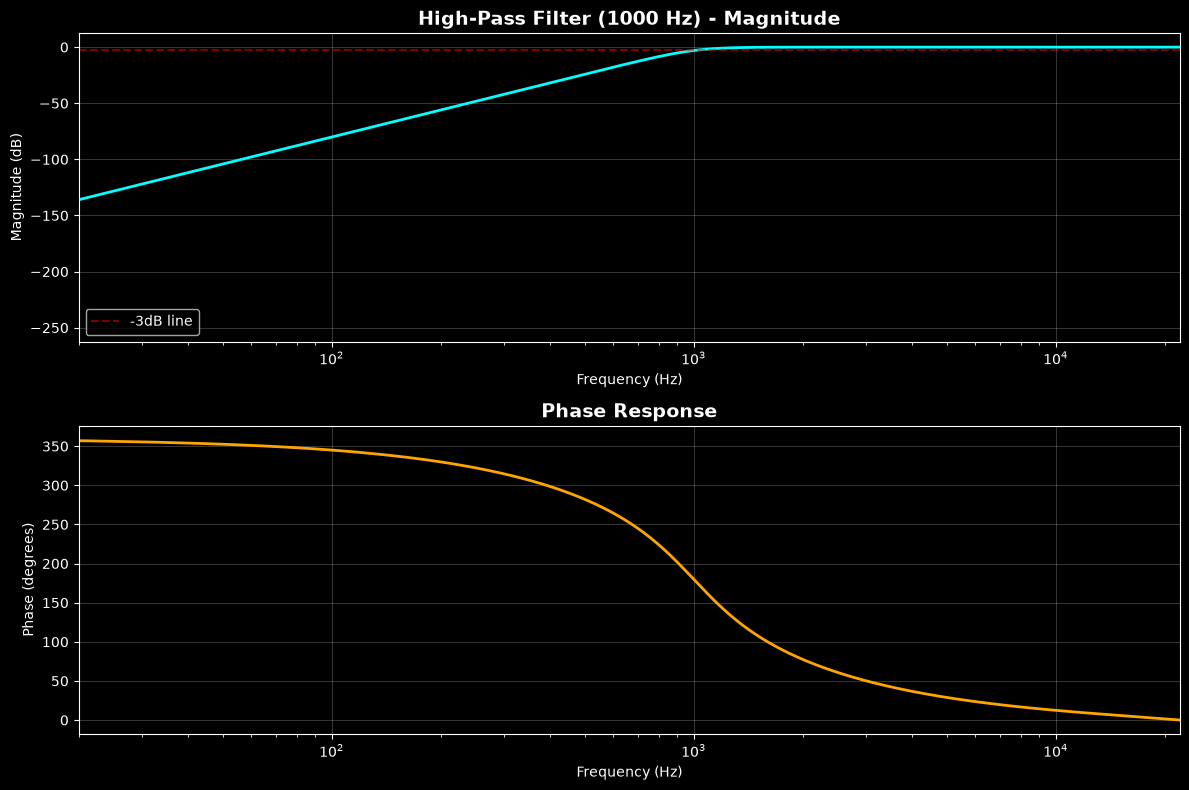

C:\Users\raine.DESKTOP\AppData\Local\Temp\ipykernel_26872\1275149850.py:13: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(w, 20 * np.log10(abs(h)), "cyan", linewidth=2)


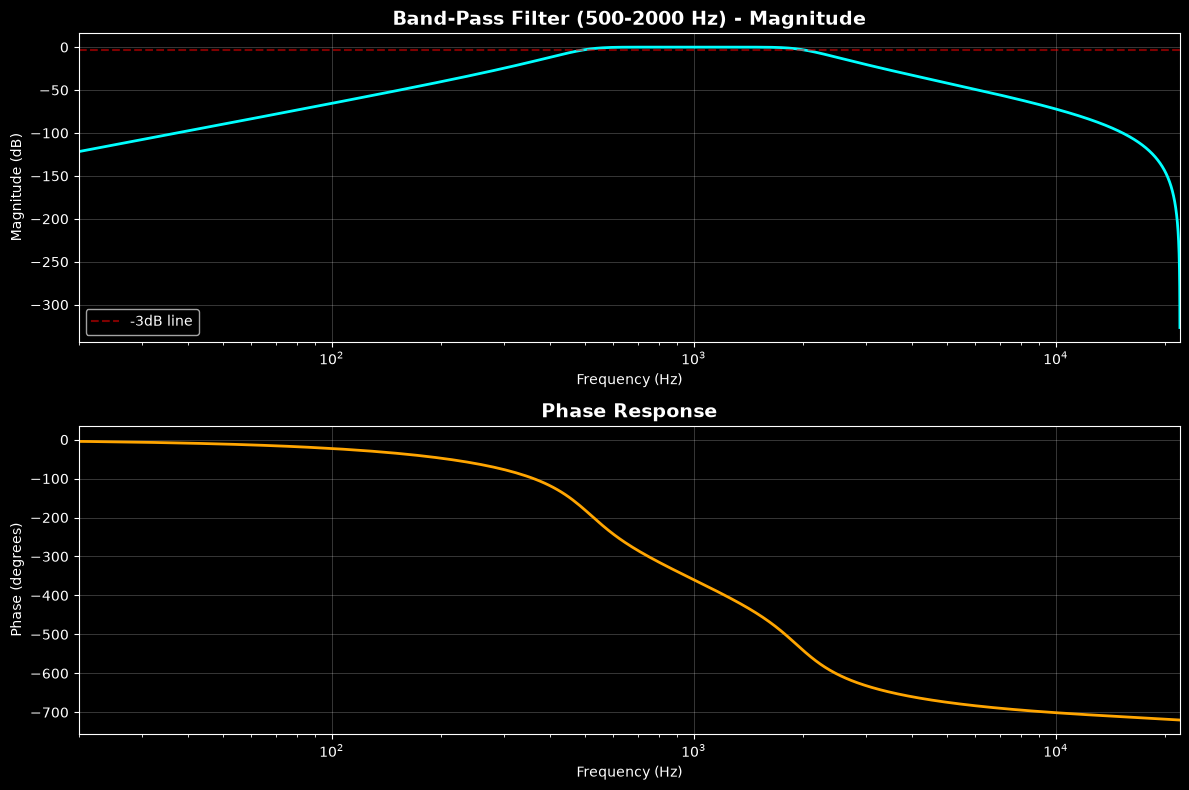

In [3]:
def plot_frequency_response(filt, title="Frequency Response"):
    """Plot the frequency response of a filter."""
    # Get filter coefficients
    b, a = filt._b, filt._a

    # Calculate frequency response
    w, h = sig.freqz(b, a, worN=2048, fs=filt.sample_rate)

    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Magnitude response
    ax1.plot(w, 20 * np.log10(abs(h)), "cyan", linewidth=2)
    ax1.set_title(f"{title} - Magnitude", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Magnitude (dB)")
    ax1.set_xlim(20, filt.sample_rate / 2)
    ax1.set_xscale("log")
    ax1.grid(True, alpha=0.3)
    ax1.axhline(-3, color="red", linestyle="--", alpha=0.5, label="-3dB line")
    ax1.legend()

    # Phase response
    angles = np.unwrap(np.angle(h))
    ax2.plot(w, np.degrees(angles), "orange", linewidth=2)
    ax2.set_title("Phase Response", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Phase (degrees)")
    ax2.set_xlim(20, filt.sample_rate / 2)
    ax2.set_xscale("log")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Plot different filter types
plot_frequency_response(lpf, "Low-Pass Filter (1000 Hz)")
plot_frequency_response(hpf, "High-Pass Filter (1000 Hz)")
plot_frequency_response(bpf, "Band-Pass Filter (500-2000 Hz)")

## 3. Effect of Filter Order

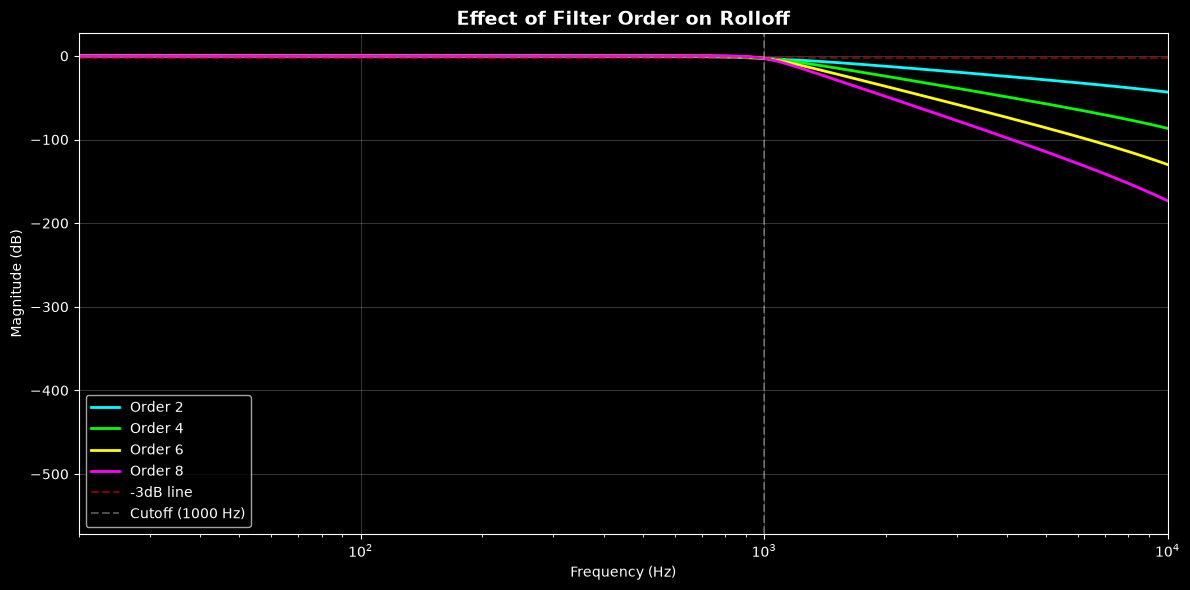

📊 Higher order = Steeper rolloff (sharper cutoff)


In [4]:
# Compare different filter orders
fig, ax = plt.subplots(figsize=(12, 6))

orders = [2, 4, 6, 8]
colors = ["cyan", "lime", "yellow", "magenta"]

for order, color in zip(orders, colors, strict=False):
    filt = ButterworthFilter(cutoff=1000, filter_type="low", order=order)
    b, a = filt._b, filt._a
    w, h = sig.freqz(b, a, worN=2048, fs=filt.sample_rate)
    ax.plot(w, 20 * np.log10(abs(h)), color=color, linewidth=2, label=f"Order {order}")

ax.set_title("Effect of Filter Order on Rolloff", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_xlim(20, 10000)
ax.set_xscale("log")
ax.axhline(-3, color="red", linestyle="--", alpha=0.5, label="-3dB line")
ax.axvline(1000, color="white", linestyle="--", alpha=0.3, label="Cutoff (1000 Hz)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("📊 Higher order = Steeper rolloff (sharper cutoff)")

## 4. Filtering Audio Signals

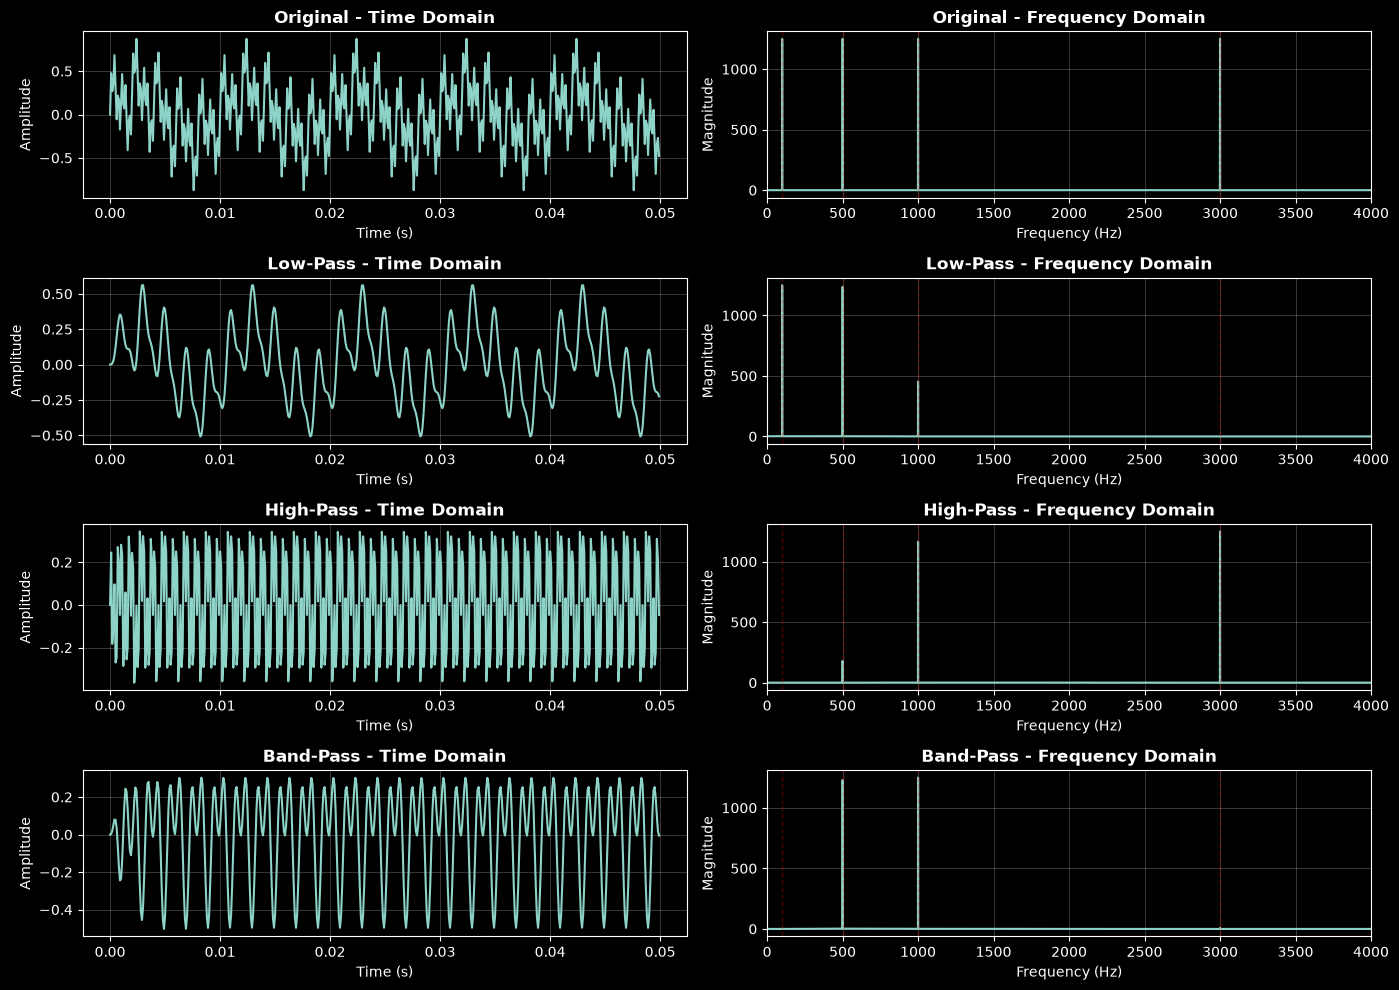

📊 Frequency components in original signal: 100, 500, 1000, 3000 Hz
   Low-pass (800 Hz): Keeps 100, 500 Hz - attenuates 1000, 3000 Hz
   High-pass (800 Hz): Keeps 1000, 3000 Hz - attenuates 100, 500 Hz
   Band-pass (400-1500 Hz): Keeps 500, 1000 Hz - attenuates 100, 3000 Hz


In [5]:
# Generate a test signal with multiple frequency components
duration = 1.0
sample_rate = 10000
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Mix of frequencies: 100 Hz, 500 Hz, 1000 Hz, 3000 Hz
freq_components = [100, 500, 1000, 3000]
signal_in = sum(np.sin(2 * np.pi * f * t) for f in freq_components) / len(
    freq_components
)

# Create filters
lpf_demo = ButterworthFilter(
    cutoff=800, filter_type="low", order=4, sample_rate=sample_rate
)
hpf_demo = ButterworthFilter(
    cutoff=800, filter_type="high", order=4, sample_rate=sample_rate
)
bpf_demo = ButterworthFilter(
    cutoff=(400, 1500), filter_type="band", order=4, sample_rate=sample_rate
)

# Apply filters
signal_lpf = lpf_demo.scale_vectorized(signal_in.astype(np.float32))
signal_hpf = hpf_demo.scale_vectorized(signal_in.astype(np.float32))
signal_bpf = bpf_demo.scale_vectorized(signal_in.astype(np.float32))

# Visualize signals
fig, axes = plt.subplots(4, 2, figsize=(14, 10))

# Time domain
for ax, signal, title in zip(
    axes[:, 0],
    [signal_in, signal_lpf, signal_hpf, signal_bpf],
    ["Original", "Low-Pass", "High-Pass", "Band-Pass"],
    strict=False,
):
    ax.plot(t[:500], signal[:500], linewidth=1.5)
    ax.set_title(f"{title} - Time Domain", fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)

# Frequency domain
for ax, signal, title in zip(
    axes[:, 1],
    [signal_in, signal_lpf, signal_hpf, signal_bpf],
    ["Original", "Low-Pass", "High-Pass", "Band-Pass"],
    strict=False,
):
    fft = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), 1 / sample_rate)
    ax.plot(freqs, fft, linewidth=1.5)
    ax.set_title(f"{title} - Frequency Domain", fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude")
    ax.set_xlim(0, 4000)
    ax.grid(True, alpha=0.3)

    # Mark frequency components
    for f in freq_components:
        ax.axvline(f, color="red", linestyle="--", alpha=0.3, linewidth=1)

plt.tight_layout()
plt.show()

print("📊 Frequency components in original signal: 100, 500, 1000, 3000 Hz")
print("   Low-pass (800 Hz): Keeps 100, 500 Hz - attenuates 1000, 3000 Hz")
print("   High-pass (800 Hz): Keeps 1000, 3000 Hz - attenuates 100, 500 Hz")
print("   Band-pass (400-1500 Hz): Keeps 500, 1000 Hz - attenuates 100, 3000 Hz")

## 5. Real-World Example: Filtering Oscillators

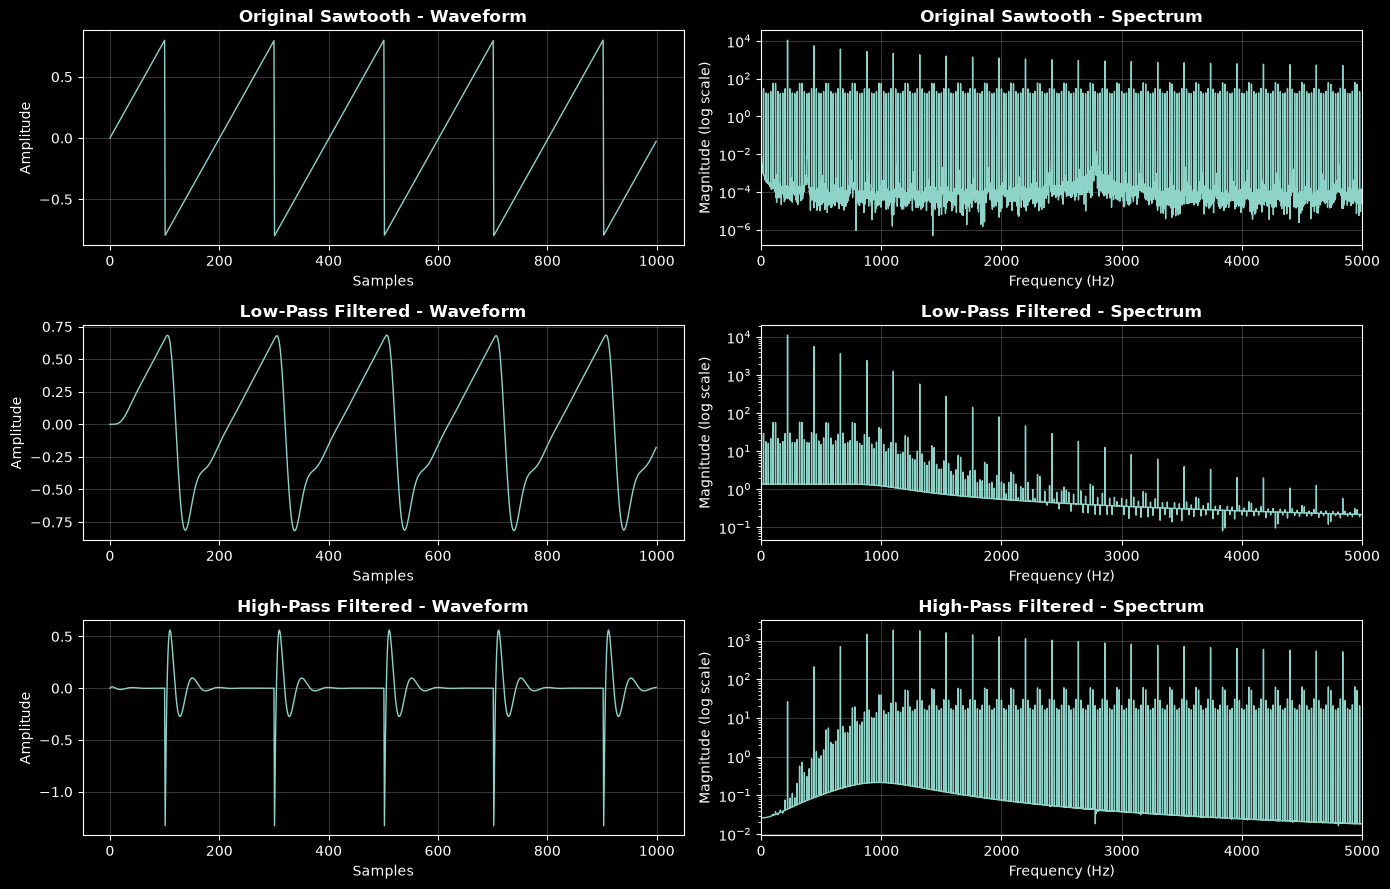

🎵 Sawtooth wave has many harmonics
   Low-pass: Removes high harmonics → warmer, softer sound
   High-pass: Removes low harmonics → thinner, brighter sound


In [6]:
# Create a sawtooth oscillator (rich in harmonics)
saw_osc = SawtoothOscillator(
    frequency=220, amplitude=0.8, sample_rate=DEFAULT_SAMPLE_RATE
)
saw_signal = saw_osc.get_samples_vectorized(DEFAULT_SAMPLE_RATE)  # 1 second

# Apply different filters
lpf_saw = ButterworthFilter(cutoff=1000, filter_type="low", order=4)
hpf_saw = ButterworthFilter(cutoff=1000, filter_type="high", order=4)

saw_filtered_lp = lpf_saw.scale_vectorized(saw_signal)
saw_filtered_hp = hpf_saw.scale_vectorized(saw_signal)

# Visualize
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

# Time domain
for ax, signal, title in zip(
    axes[:, 0],
    [saw_signal, saw_filtered_lp, saw_filtered_hp],
    ["Original Sawtooth", "Low-Pass Filtered", "High-Pass Filtered"],
    strict=False,
):
    ax.plot(signal[:1000], linewidth=1)
    ax.set_title(f"{title} - Waveform", fontweight="bold")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)

# Frequency domain
for ax, signal, title in zip(
    axes[:, 1],
    [saw_signal, saw_filtered_lp, saw_filtered_hp],
    ["Original Sawtooth", "Low-Pass Filtered", "High-Pass Filtered"],
    strict=False,
):
    fft = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), 1 / DEFAULT_SAMPLE_RATE)
    ax.semilogy(freqs[:5000], fft[:5000], linewidth=1)
    ax.set_title(f"{title} - Spectrum", fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (log scale)")
    ax.set_xlim(0, 5000)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🎵 Sawtooth wave has many harmonics")
print("   Low-pass: Removes high harmonics → warmer, softer sound")
print("   High-pass: Removes low harmonics → thinner, brighter sound")

## 6. Noise Filtering

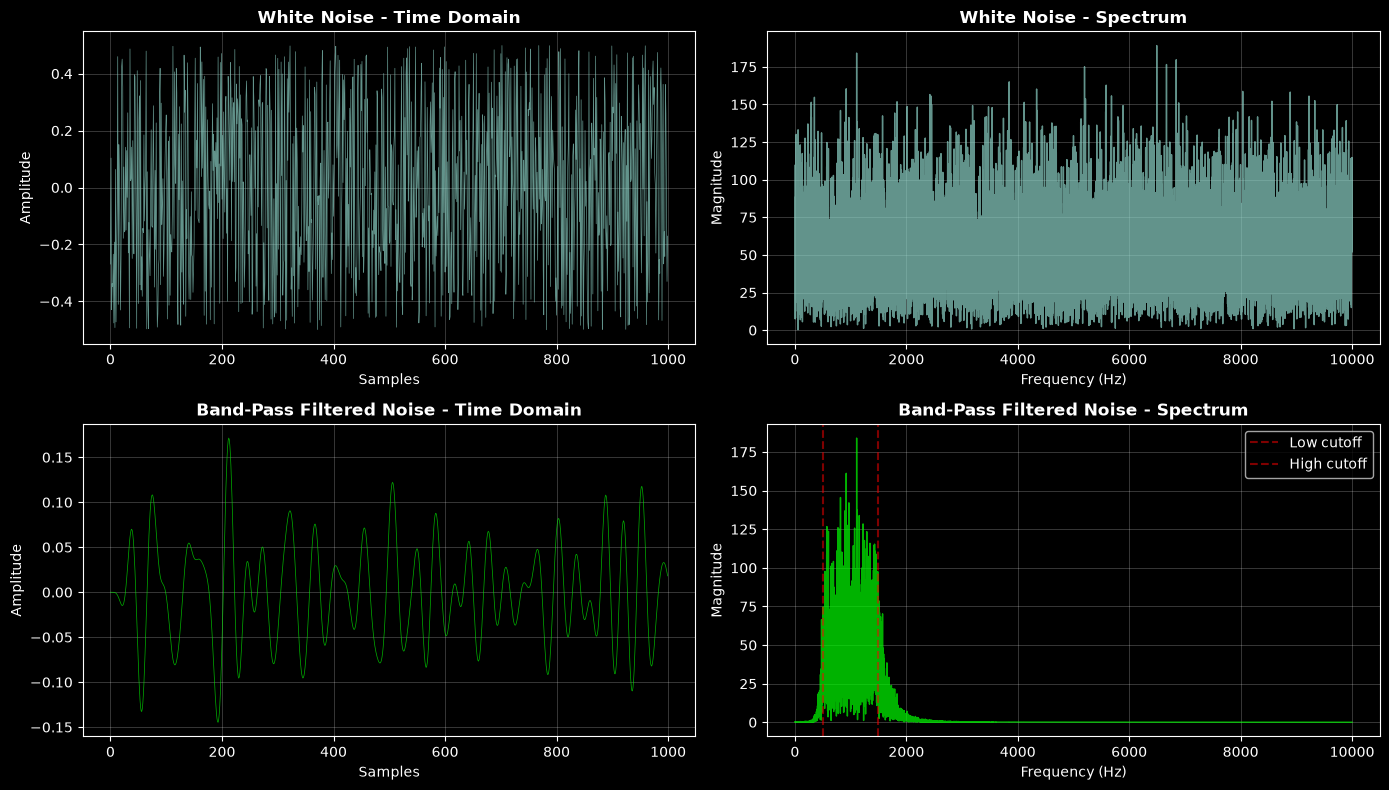

🔊 Band-pass filter creates 'resonant' colored noise
   Useful for: wind effects, ocean sounds, synthesis textures


In [7]:
# Generate white noise
noise_gen = NoiseGenerator(
    noise_type="White", amplitude=0.5, sample_rate=DEFAULT_SAMPLE_RATE
)
noise_signal = noise_gen.get_samples_vectorized(DEFAULT_SAMPLE_RATE)

# Apply band-pass filter to create colored noise
bp_filter = ButterworthFilter(cutoff=(500, 1500), filter_type="band", order=6)
colored_noise = bp_filter.scale_vectorized(noise_signal)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time domain
axes[0, 0].plot(noise_signal[:1000], linewidth=0.5, alpha=0.7)
axes[0, 0].set_title("White Noise - Time Domain", fontweight="bold")
axes[0, 0].set_xlabel("Samples")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(colored_noise[:1000], linewidth=0.5, alpha=0.7, color="lime")
axes[1, 0].set_title("Band-Pass Filtered Noise - Time Domain", fontweight="bold")
axes[1, 0].set_xlabel("Samples")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].grid(True, alpha=0.3)

# Frequency domain
fft_white = np.abs(np.fft.rfft(noise_signal))
fft_colored = np.abs(np.fft.rfft(colored_noise))
freqs = np.fft.rfftfreq(len(noise_signal), 1 / DEFAULT_SAMPLE_RATE)

axes[0, 1].plot(freqs[:10000], fft_white[:10000], linewidth=1, alpha=0.7)
axes[0, 1].set_title("White Noise - Spectrum", fontweight="bold")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Magnitude")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].plot(
    freqs[:10000], fft_colored[:10000], linewidth=1, alpha=0.7, color="lime"
)
axes[1, 1].axvline(500, color="red", linestyle="--", alpha=0.5, label="Low cutoff")
axes[1, 1].axvline(1500, color="red", linestyle="--", alpha=0.5, label="High cutoff")
axes[1, 1].set_title("Band-Pass Filtered Noise - Spectrum", fontweight="bold")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Magnitude")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔊 Band-pass filter creates 'resonant' colored noise")
print("   Useful for: wind effects, ocean sounds, synthesis textures")

## 7. Dynamic Filter Sweeps

C:\Users\raine.DESKTOP\AppData\Local\Temp\ipykernel_26872\1589771714.py:31: RuntimeWarning: divide by zero encountered in log10
  ax1.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading="gouraud", cmap="hot")


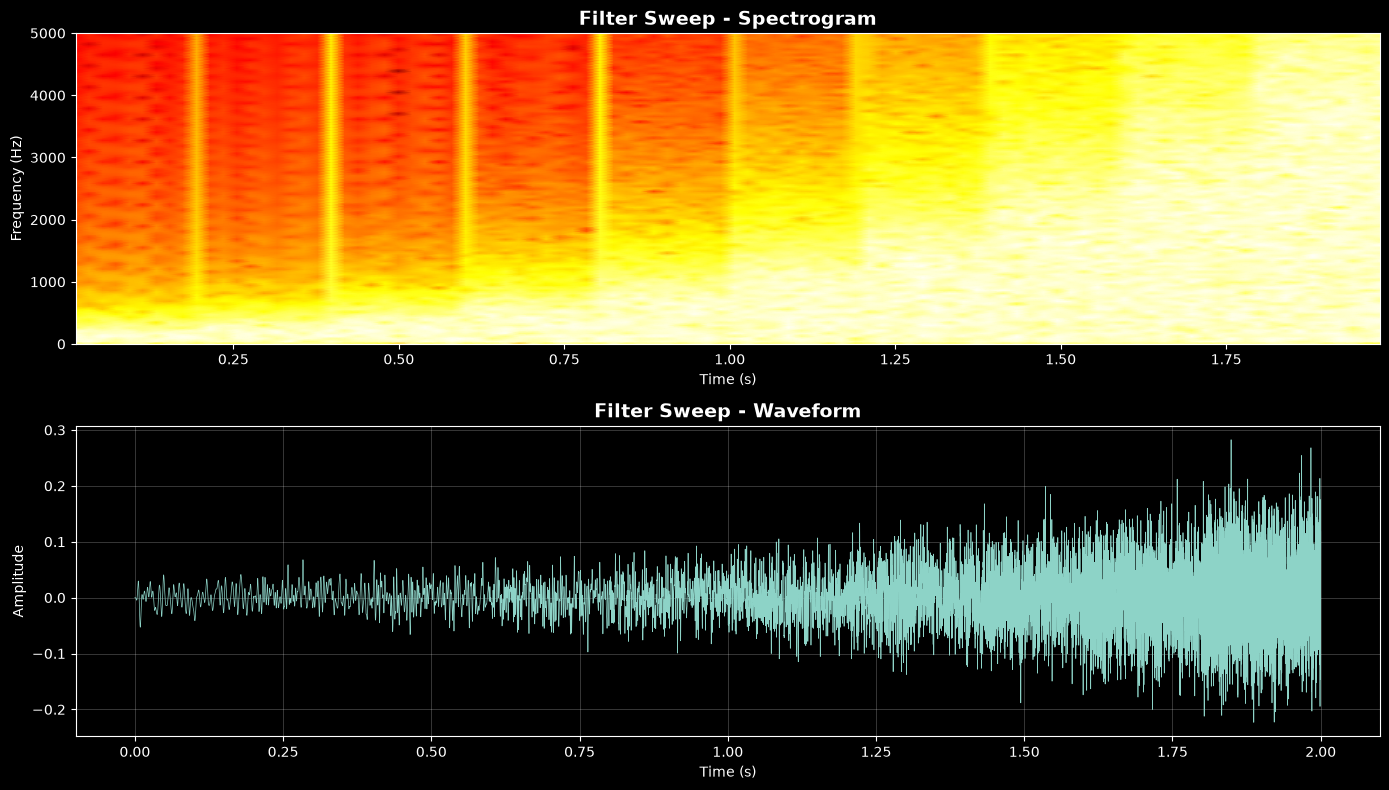

🌊 Filter sweep: Moving cutoff frequency creates sweeping effect
   Sweep range: 200 Hz → 4000 Hz


In [8]:
# Create a filter sweep effect
duration = 2.0
sample_rate = DEFAULT_SAMPLE_RATE
num_samples = int(sample_rate * duration)

# Generate white noise
noise = NoiseGenerator(
    noise_type="White", amplitude=0.3, sample_rate=sample_rate
).get_samples_vectorized(num_samples)

# Sweep the cutoff frequency from 200 Hz to 4000 Hz
cutoff_sweep = np.logspace(np.log10(200), np.log10(4000), 10)
filtered_sweep = np.zeros_like(noise)

# Apply filter in chunks with different cutoffs
chunk_size = len(noise) // len(cutoff_sweep)
for i, cutoff in enumerate(cutoff_sweep):
    filt = ButterworthFilter(
        cutoff=cutoff, filter_type="low", order=6, sample_rate=sample_rate
    )
    start = i * chunk_size
    end = start + chunk_size if i < len(cutoff_sweep) - 1 else len(noise)
    filtered_sweep[start:end] = filt.scale_vectorized(noise[start:end])

# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))


# Spectrogram
f, t_spec, Sxx = sig.spectrogram(filtered_sweep, sample_rate, nperseg=1024)
ax1.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading="gouraud", cmap="hot")
ax1.set_ylabel("Frequency (Hz)")
ax1.set_xlabel("Time (s)")
ax1.set_title("Filter Sweep - Spectrogram", fontsize=14, fontweight="bold")
ax1.set_ylim(0, 5000)

# Waveform
ax2.plot(
    np.linspace(0, duration, num_samples, endpoint=False), filtered_sweep, linewidth=0.5
)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.set_title("Filter Sweep - Waveform", fontsize=14, fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🌊 Filter sweep: Moving cutoff frequency creates sweeping effect")
print(f"   Sweep range: {cutoff_sweep[0]:.0f} Hz → {cutoff_sweep[-1]:.0f} Hz")

## 8. Integration with Chain

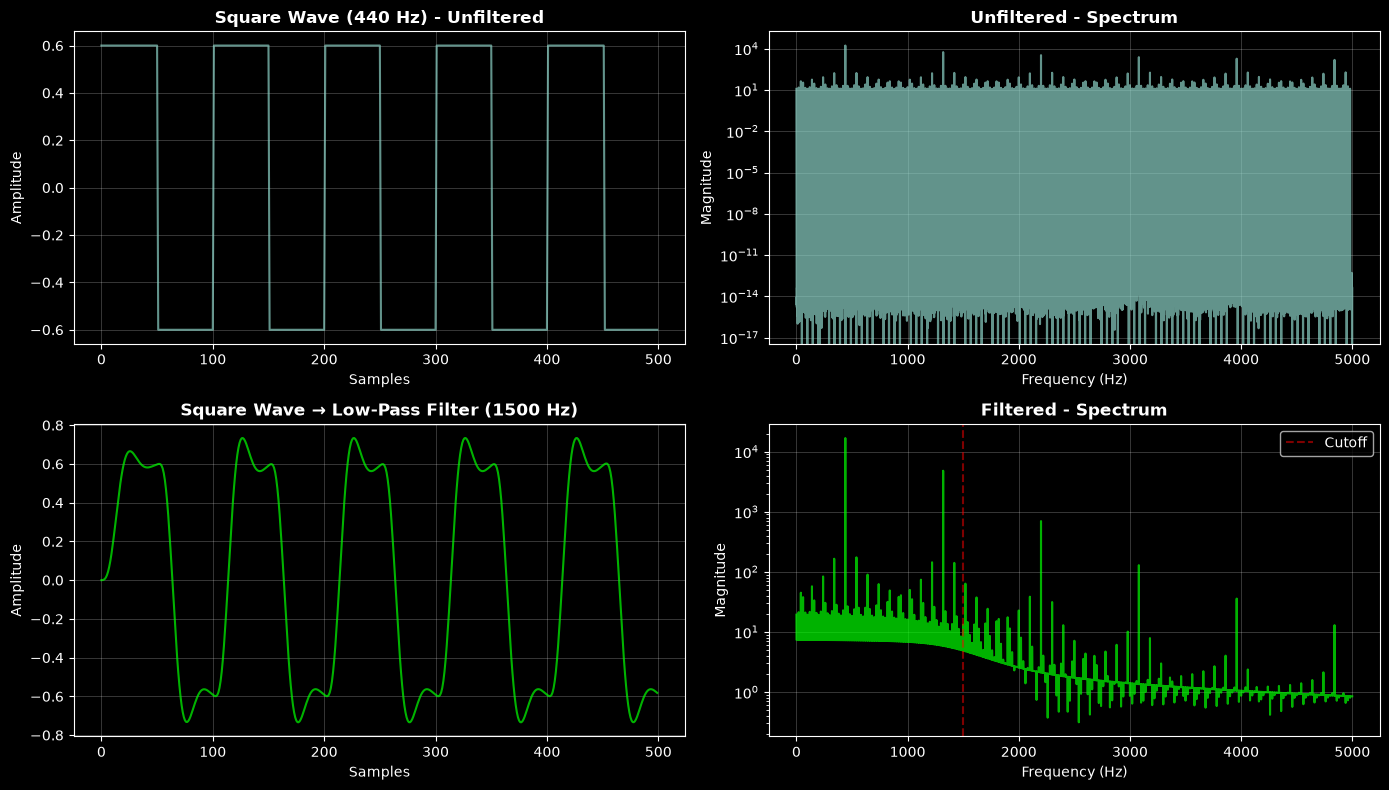

⛓️ Chain: Oscillator → Filter → Output
   Filter removes high-frequency harmonics from square wave


In [9]:
# Create a complete signal chain
osc = SquareOscillator(frequency=440, amplitude=0.6)
lpf_chain = ButterworthFilter(cutoff=1500, filter_type="low", order=4)

# Build chain
audio_chain = Chain(osc, lpf_chain)

# Generate samples
chain_output = audio_chain.get_samples(DEFAULT_SAMPLE_RATE, mode="vectorized")

# Compare unfiltered vs filtered
unfiltered = osc.get_samples_vectorized(DEFAULT_SAMPLE_RATE)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Waveforms
axes[0, 0].plot(unfiltered[:500], label="Unfiltered", alpha=0.7)
axes[0, 0].set_title("Square Wave (440 Hz) - Unfiltered", fontweight="bold")
axes[0, 0].set_xlabel("Samples")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(chain_output[:500], color="lime", label="Filtered", alpha=0.7)
axes[1, 0].set_title("Square Wave → Low-Pass Filter (1500 Hz)", fontweight="bold")
axes[1, 0].set_xlabel("Samples")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].grid(True, alpha=0.3)

# Spectra
fft_unfilt = np.abs(np.fft.rfft(unfiltered))
fft_filt = np.abs(np.fft.rfft(chain_output))
freqs = np.fft.rfftfreq(len(unfiltered), 1 / DEFAULT_SAMPLE_RATE)

axes[0, 1].semilogy(freqs[:5000], fft_unfilt[:5000], alpha=0.7)
axes[0, 1].set_title("Unfiltered - Spectrum", fontweight="bold")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Magnitude")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].semilogy(freqs[:5000], fft_filt[:5000], color="lime", alpha=0.7)
axes[1, 1].axvline(1500, color="red", linestyle="--", alpha=0.5, label="Cutoff")
axes[1, 1].set_title("Filtered - Spectrum", fontweight="bold")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Magnitude")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("⛓️ Chain: Oscillator → Filter → Output")
print("   Filter removes high-frequency harmonics from square wave")

## 9. Performance Comparison

⚡ Performance Benchmark
   Vectorized: 0.30 ms per second of audio
   Throughput: 147.1M samples/sec
   Realtime factor: 3336x
Filter coefficients designed:
  b (numerator): 7 coefficients
  a (denominator): 7 coefficients


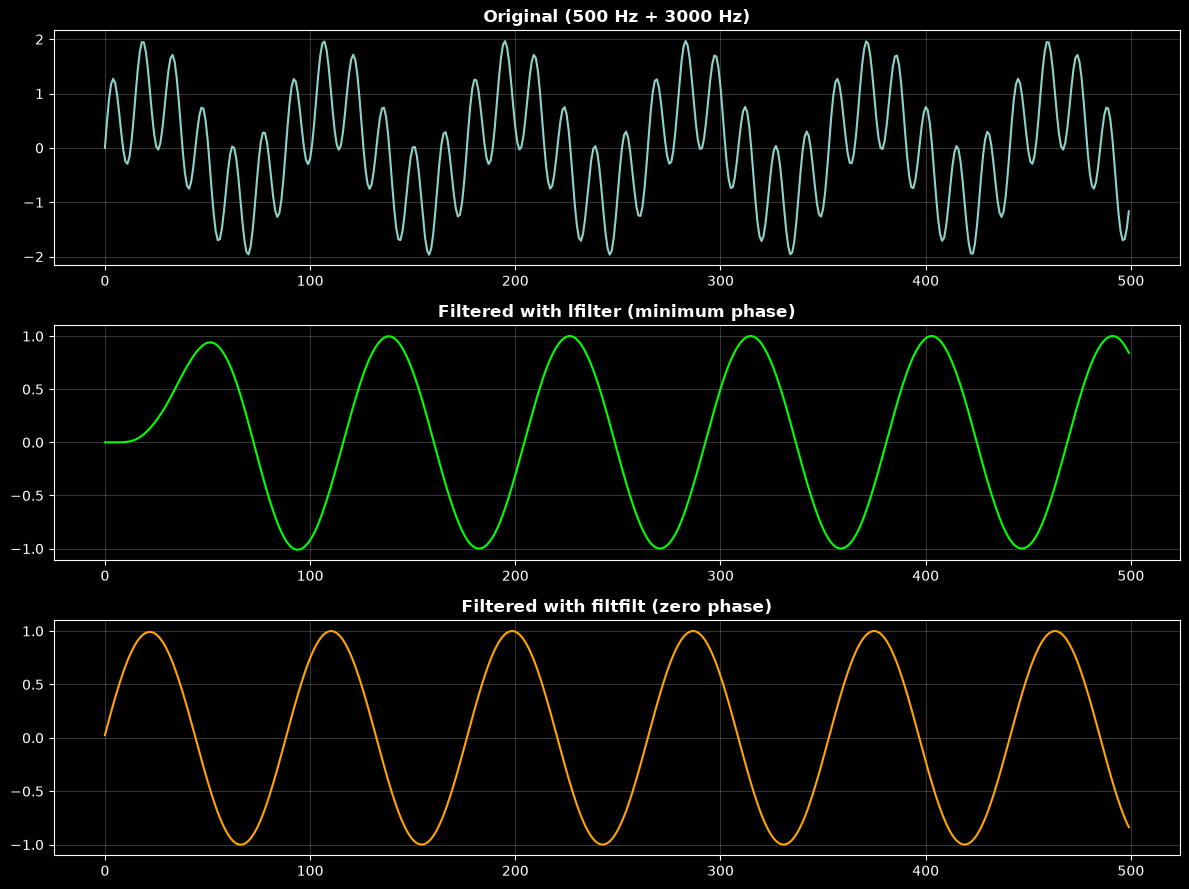

📊 filtfilt (zero-phase) has no phase distortion but is 2x slower
   lfilter (minimum phase) is faster but introduces phase shift


In [10]:
import time

# Test vectorized vs sample-by-sample performance
test_signal = np.random.randn(DEFAULT_SAMPLE_RATE).astype(np.float32)
filt = ButterworthFilter(cutoff=1000, filter_type="low", order=4)

# Vectorized
start = time.time()
for _ in range(10):
    result_vec = filt.scale_vectorized(test_signal)
time_vec = (time.time() - start) / 10

print("⚡ Performance Benchmark")
print(f"   Vectorized: {time_vec*1000:.2f} ms per second of audio")
print(f"   Throughput: {DEFAULT_SAMPLE_RATE/time_vec/1e6:.1f}M samples/sec")
print(f"   Realtime factor: {1.0/time_vec:.0f}x")

# %% [markdown]
# ## 10. Utility Functions

# %%
# Using the standalone utility functions
b, a = butter(order=6, cutoff=1000, fs=DEFAULT_SAMPLE_RATE, btype="low")
print("Filter coefficients designed:")
print(f"  b (numerator): {len(b)} coefficients")
print(f"  a (denominator): {len(a)} coefficients")

# Generate test signal
test_sig = np.sin(2 * np.pi * 500 * np.linspace(0, 1, DEFAULT_SAMPLE_RATE))
test_sig += np.sin(2 * np.pi * 3000 * np.linspace(0, 1, DEFAULT_SAMPLE_RATE))

# Apply filter using utility function (zero-phase)
filtered_util = apply_filter(b, a, test_sig)

# Compare with lfilter (minimum phase)
filtered_min_phase = lfilter(b, a, test_sig)

# Visualize
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(test_sig[:500])
axes[0].set_title("Original (500 Hz + 3000 Hz)", fontweight="bold")
axes[0].grid(True, alpha=0.3)

axes[1].plot(filtered_min_phase[:500], color="lime")
axes[1].set_title("Filtered with lfilter (minimum phase)", fontweight="bold")
axes[1].grid(True, alpha=0.3)

axes[2].plot(filtered_util[:500], color="orange")
axes[2].set_title("Filtered with filtfilt (zero phase)", fontweight="bold")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 filtfilt (zero-phase) has no phase distortion but is 2x slower")
print("   lfilter (minimum phase) is faster but introduces phase shift")

## Summary

### Key Takeaways:

1. **Filter Types**:
   - Low-pass: Removes high frequencies (warmth, bass)
   - High-pass: Removes low frequencies (brightness, air)
   - Band-pass: Keeps only mid frequencies (telephone effect, resonance)
2. **Filter Order**:
   - Higher order = Steeper rolloff (sharper cutoff)
   - Typical range: 2-8
   - Default: 4 (good balance)

3. **Performance**:
   - Vectorized processing: 100-1000x realtime
   - Recommended for batch processing

4. **Use Cases**:
   - Tone shaping (subtractive synthesis)
   - Noise coloring
   - Sound design effects
   - Signal cleanup

5. **Integration**:
   - Works seamlessly with Chain, oscillators, and other components
   - Dynamic parameter updates supported
   - Both vectorized and stateful modes available

### Next Steps:
- Try creating your own filter chains
- Experiment with different cutoff frequencies
- Combine multiple filters for complex effects
- Use with ADSR envelopes for dynamic filtering
